# MT Predictor: dataset and derived route audit

This notebook verifies mappings, schedules, route cycles and GPS geometry. Derived GPS lines are for dashboard visualization only and are not ML features.

In [1]:
from pathlib import Path
import json, sys
import matplotlib.pyplot as plt
import pandas as pd
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parents[1]
sys.path.insert(0, str(ROOT / 'data_pipeline'))
from route_catalog.builder import load_dataset, build_catalog
dataset_dir = ROOT.parent.parent / 'dataset'
bundle = load_dataset(dataset_dir)
catalog, bindings, quality = build_catalog(bundle)
quality

{'schema_version': 1,
 'traffic_files_test_validate_identical': True,
 'binding_count': 56,
 'real_binding_count': 30,
 'real_with_schedule_count': 13,
 'real_without_schedule_count': 17,
 'physical_stop_count': 847,
 'route_pattern_count': 31,
 'assignment_count': 311,
 'geometry_quality_counts': {'gps_repeated': 20,
  'stops_only': 6,
  'gps_single': 5},
 'patterns': [{'route_pattern_id': 'route_pattern_0fb0f312098c',
   'occurrence_count': 21,
   'good_gps_occurrence_count': 21,
   'best_stop_coverage': 1.0,
   'median_stop_to_gps_m': 7.0,
   'max_gps_jump_m': 176.4,
   'polyline_point_count': 147,
   'geometry_quality': 'gps_repeated'},
  {'route_pattern_id': 'route_pattern_14a31b486db8',
   'occurrence_count': 4,
   'good_gps_occurrence_count': 2,
   'best_stop_coverage': 1.0,
   'median_stop_to_gps_m': 10.0,
   'max_gps_jump_m': 1207.6,
   'polyline_point_count': 129,
   'geometry_quality': 'gps_repeated'},
  {'route_pattern_id': 'route_pattern_1e2366da6e91',
   'occurrence_count

In [2]:
audit = []
for split, frame in bundle.traffic.items():
    audit.append({'dataset': f'{split}/traffic', 'rows': len(frame), 'tr_id': frame.tr_id.nunique(), 'unit_id': frame.unit_id.nunique(), 'valid_locations': int(frame.location_valid.sum()), 'duplicate_tr_time': int(frame.duplicated(['tr_id','event_time']).sum())})
for split, frame in bundle.schedules.items():
    audit.append({'dataset': f'{split}/schedule', 'rows': len(frame), 'tr_id': frame.tr_id.nunique(), 'unit_id': None, 'valid_locations': len(frame), 'duplicate_tr_time': int(frame.duplicated(['tr_id','time_begin']).sum())})
pd.DataFrame(audit)

,dataset,rows,tr_id,unit_id,valid_locations,duplicate_tr_time
0,train/traffic,287849,56,56.0,243974,8473
1,test/traffic,105945,30,30.0,89096,2927
2,validate/traffic,105945,30,30.0,89096,2927
3,train/schedule,16674,39,NaN,16674,540
4,test/schedule,5558,13,NaN,5558,180
5,validate/schedule,5558,13,NaN,5558,180


In [3]:
display(bindings.groupby(['synthetic','has_schedule']).size().rename('count').reset_index())
display(pd.DataFrame(quality['patterns']).sort_values(['geometry_quality','best_stop_coverage']))

,synthetic,has_schedule,count
0,False,False,17
1,False,True,13
2,True,True,26


,route_pattern_id,occurrence_count,good_gps_occurrence_count,best_stop_coverage,median_stop_to_gps_m,max_gps_jump_m,polyline_point_count,geometry_quality
4,route_pattern_289254115bf3,4,2,0.6486,22.5,222.7,83,gps_repeated
30,route_pattern_f3a26bc8e42b,4,2,0.7308,18.1,185.6,111,gps_repeated
29,route_pattern_ed125cf0eef4,4,2,0.8947,13.3,190.1,96,gps_repeated
14,route_pattern_772dfd9efd61,12,9,0.9412,8.5,275.1,70,gps_repeated
5,route_pattern_2d0893e17053,16,4,0.9753,12.5,1378.3,123,gps_repeated
0,route_pattern_0fb0f312098c,21,21,1.0000,7.0,176.4,147,gps_repeated
1,route_pattern_14a31b486db8,4,2,1.0000,10.0,1207.6,129,gps_repeated
6,route_pattern_2eb4770b69a4,9,9,1.0000,6.6,164.6,43,gps_repeated
7,route_pattern_32496aad6eea,3,3,1.0000,7.7,177.6,105,gps_repeated
9,route_pattern_45e07cd14aa2,12,12,1.0000,11.5,171.1,45,gps_repeated


PosixPath('/Users/arsenuifedorovtsev/3_year/MSK/Project/mt_predictor/data_pipeline/notebooks/route_preview.png')

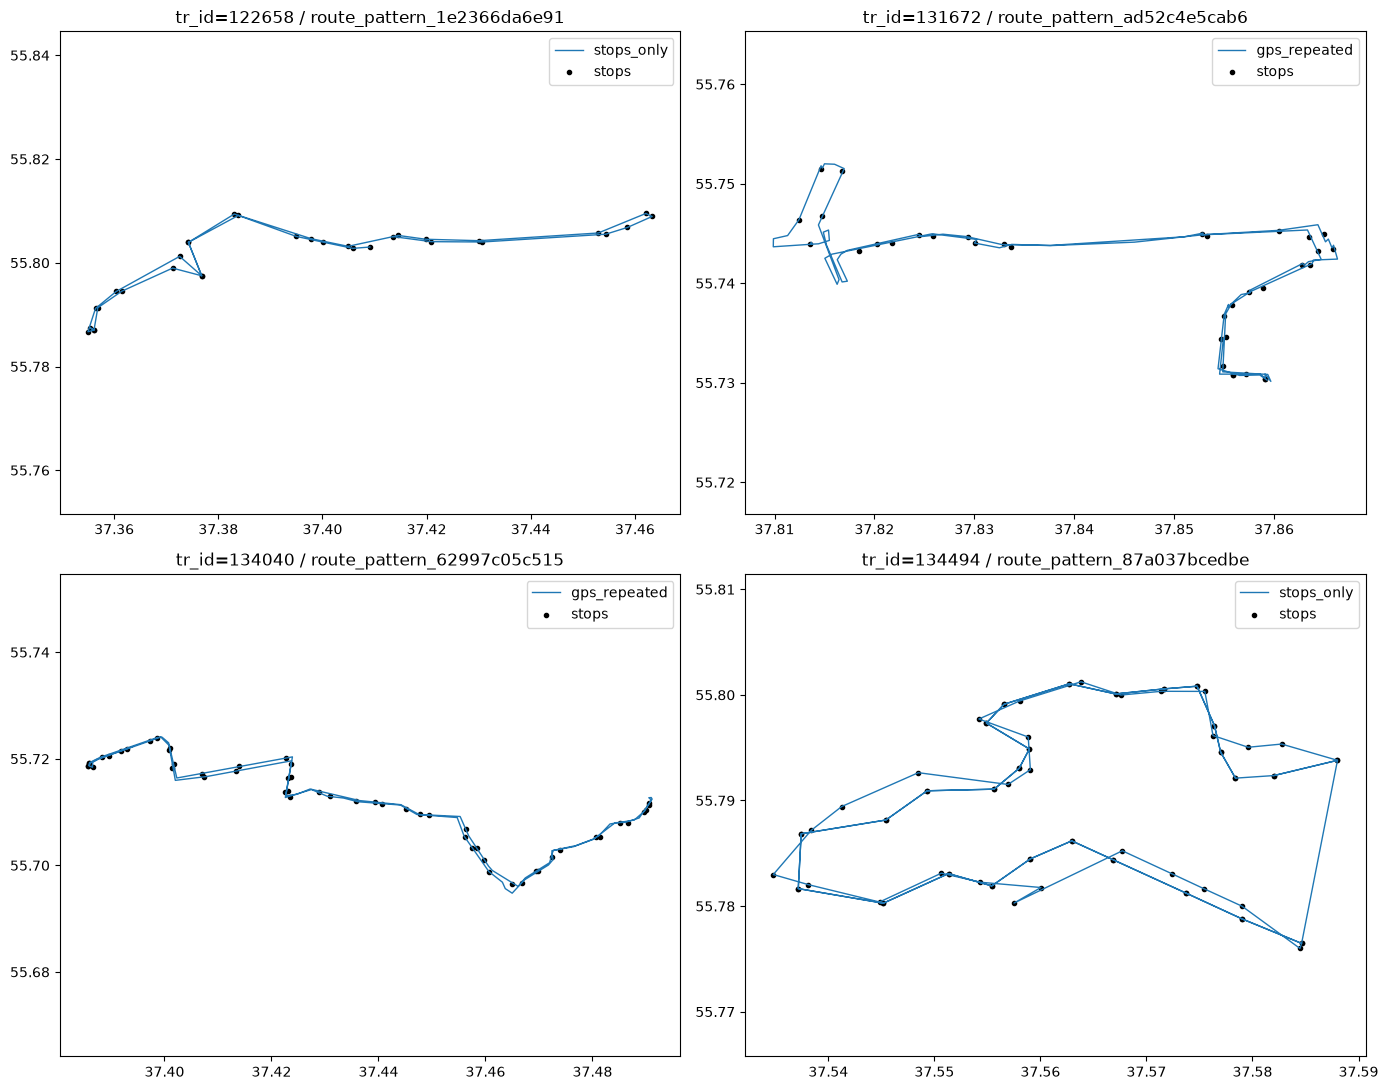

In [4]:
pattern_by_id = {p['route_pattern_id']: p for p in catalog['route_patterns']}
examples = []
for tr_id in [122658, 131672, 134040, 134494]:
    ids = []
    for assignment in catalog['assignments']:
        if assignment['tr_id'] == tr_id and assignment['route_pattern_id'] not in ids:
            ids.append(assignment['route_pattern_id'])
    if ids: examples.append((tr_id, ids[0]))
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
stops = {s['stop_id']: s for s in catalog['stops']}
for axis, (tr_id, pattern_id) in zip(axes.flat, examples):
    pattern = pattern_by_id[pattern_id]
    line = pattern['polyline']
    axis.plot([p[0] for p in line], [p[1] for p in line], '-', lw=1, label=pattern['geometry_quality'])
    route_stops = [stops[s] for s in pattern['stop_ids']]
    axis.scatter([s['lon'] for s in route_stops], [s['lat'] for s in route_stops], s=9, c='black', label='stops')
    axis.set_title(f'tr_id={tr_id} / {pattern_id}')
    axis.legend()
    axis.set_aspect('equal', adjustable='datalim')
fig.tight_layout()
preview = ROOT / 'data_pipeline' / 'notebooks' / 'route_preview.png'
fig.savefig(preview, dpi=130)
preview

## Interpretation

- `unit_id ↔ tr_id` is one-to-one in the supplied files, but remains a separate lookup.
- Vehicles without schedule are retained as `no_schedule`.
- `route_pattern_id` is derived and is not an official public route number.
- `stops_only` is an explicit fallback where telemetry does not support a truthful road geometry.